# Assignment No.11

# Data Preparation

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel("heart_disease.xlsx", sheet_name="Heart_disease")
print(df.shape)
print(df.dtypes)
print(df.head())

(908, 13)
age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs            bool
restecg      object
thalch        int64
exang        object
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object
   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  False      2.3  downsloping  fixed defect    0  
1  False      0.0         flat  fixed defect    0  
2  False      0.4         flat  fixed defect    0  
3  False      0.0         f

# Exploratory Data Analysis 

In [10]:
print(df.describe(include='all'))
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nTarget Distribution:\n", df['num'].value_counts())

               age   sex            cp    trestbps        chol    fbs restecg  \
count   908.000000   908           908  908.000000  908.000000    908     908   
unique         NaN     2             4         NaN         NaN      2       3   
top            NaN  Male  asymptomatic         NaN         NaN  False  normal   
freq           NaN   718           495         NaN         NaN    723     542   
mean     53.791850   NaN           NaN  133.430617  201.484581    NaN     NaN   
std       9.158031   NaN           NaN   20.401608  112.097949    NaN     NaN   
min      29.000000   NaN           NaN    0.000000    0.000000    NaN     NaN   
25%      47.750000   NaN           NaN  120.000000  176.750000    NaN     NaN   
50%      54.000000   NaN           NaN  130.000000  224.000000    NaN     NaN   
75%      60.000000   NaN           NaN  144.000000  270.000000    NaN     NaN   
max      77.000000   NaN           NaN  200.000000  603.000000    NaN     NaN   

            thalch  exang  

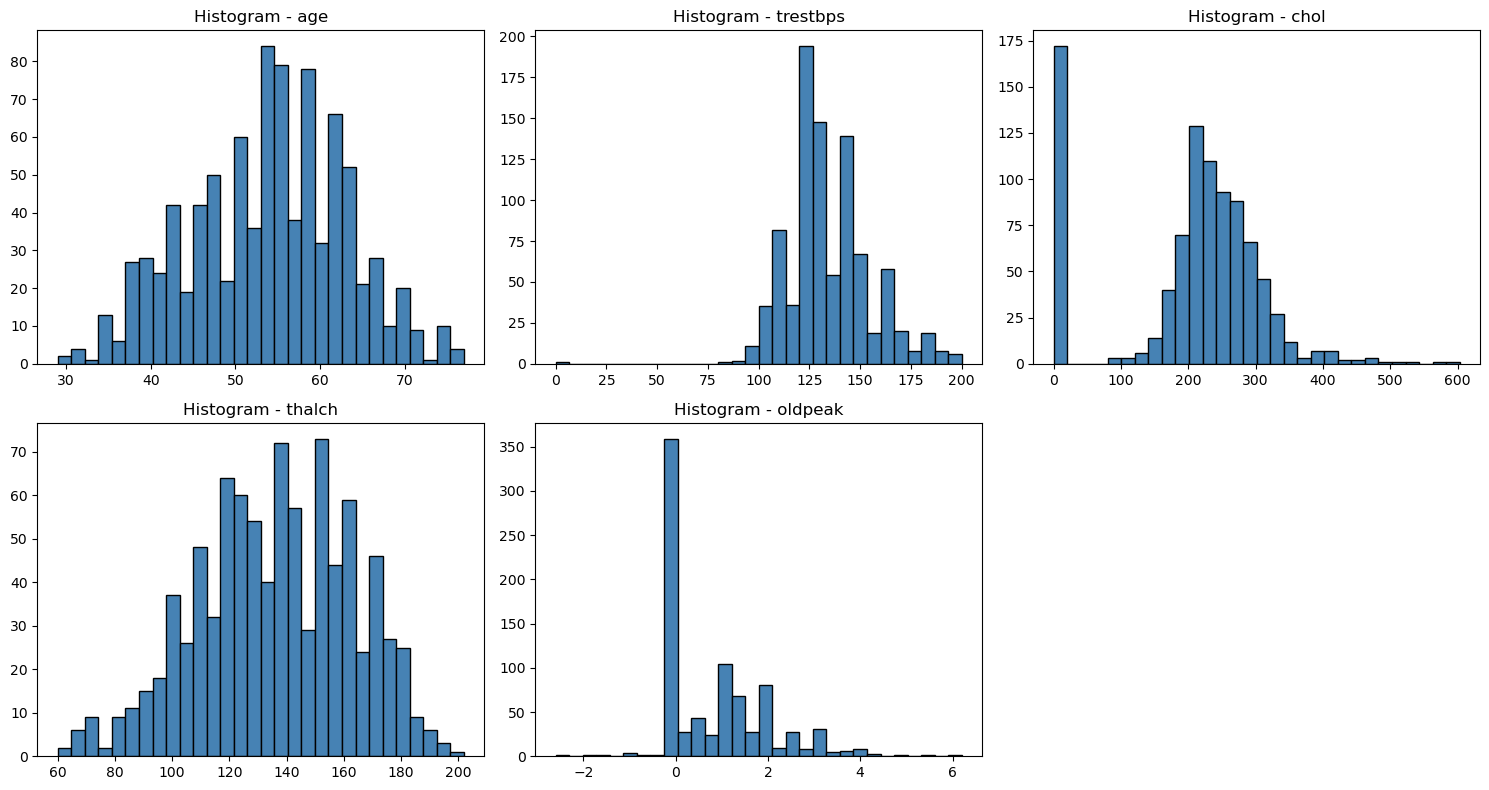

In [11]:
#Histograms
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Histogram - {col}')
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('histograms.png')
plt.show()

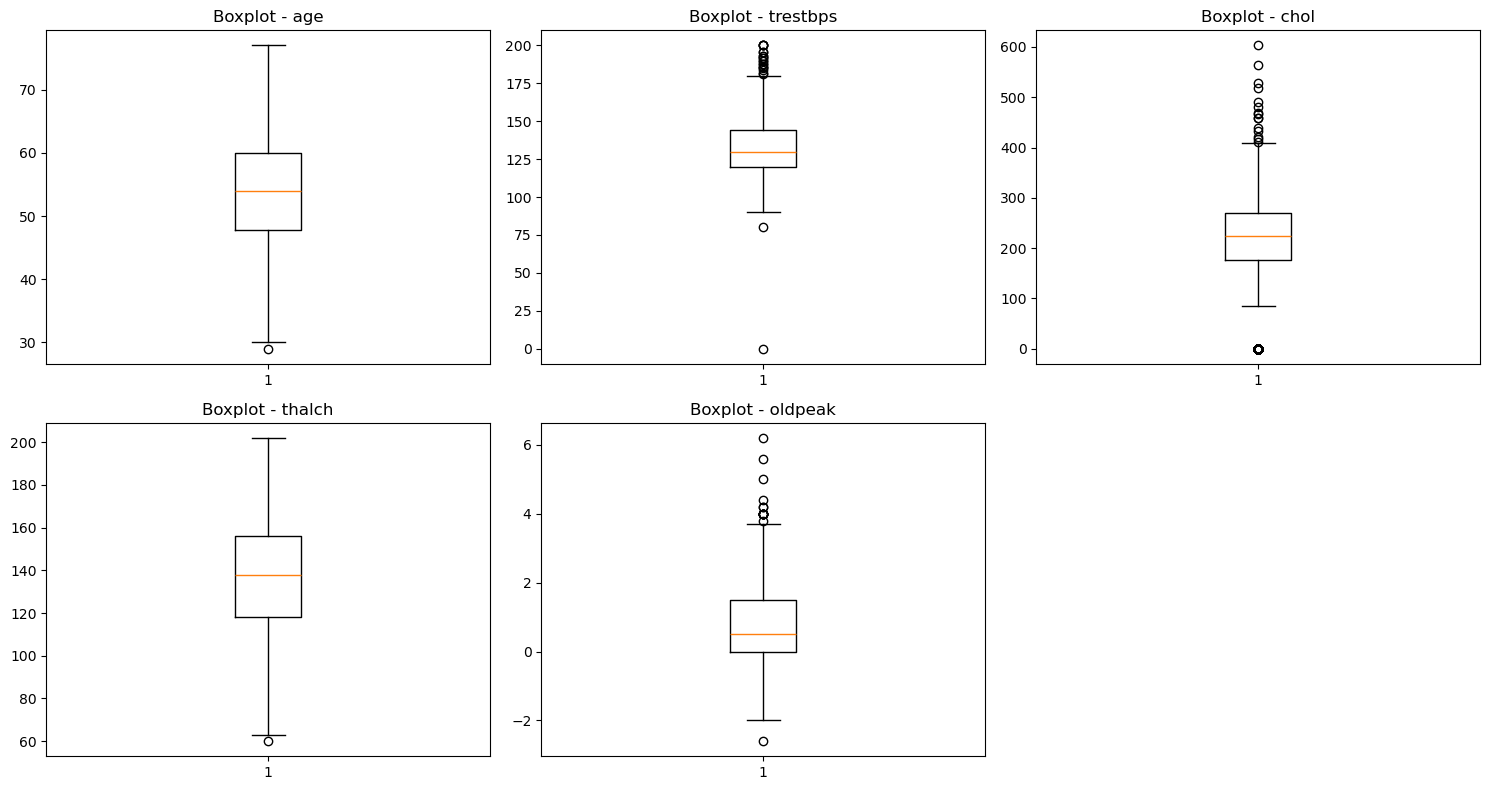

In [12]:
#Box Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot - {col}')
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('boxplots.png')
plt.show()

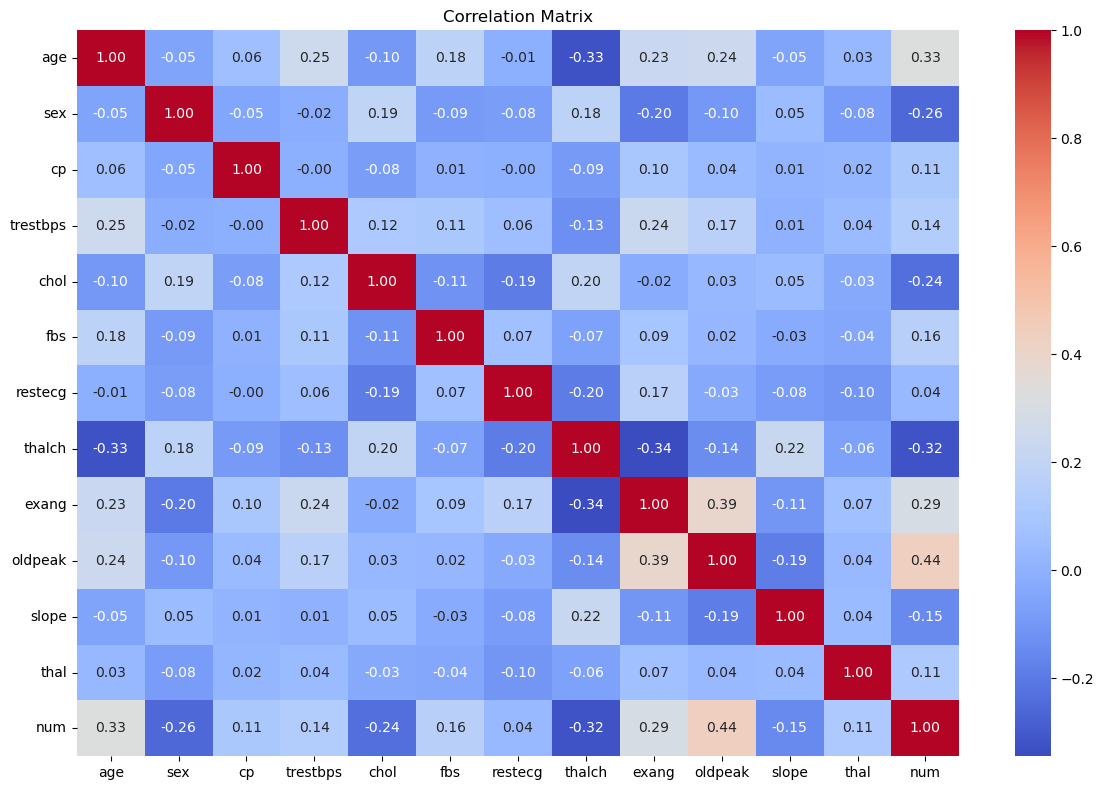

In [13]:
#Correlation Matrix
df_temp = df.copy()
for col in df_temp.select_dtypes(include='object').columns:
    df_temp[col] = pd.factorize(df_temp[col])[0]
df_temp['fbs'] = df_temp['fbs'].astype(int) if df_temp['fbs'].dtype == bool else df_temp['fbs']
df_temp['exang'] = df_temp['exang'].astype(int) if df_temp['exang'].dtype == bool else df_temp['exang']

plt.figure(figsize=(12, 8))
sns.heatmap(df_temp.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()

# Feature Engineering

In [14]:
from sklearn.preprocessing import LabelEncoder

df_clean = df.copy()

df_clean['fbs'] = df_clean['fbs'].astype(str).str.strip().str.lower().map({'true': 1, 'false': 0, '1': 1, '0': 0})
df_clean['exang'] = df_clean['exang'].astype(str).str.strip().str.lower().map({'true': 1, 'false': 0, '1': 1, '0': 0})

df_clean['oldpeak'] = pd.to_numeric(df_clean['oldpeak'], errors='coerce')
df_clean['chol'] = pd.to_numeric(df_clean['chol'], errors='coerce')
df_clean['trestbps'] = pd.to_numeric(df_clean['trestbps'], errors='coerce')
df_clean['thalch'] = pd.to_numeric(df_clean['thalch'], errors='coerce')

df_clean['oldpeak'] = df_clean['oldpeak'].fillna(df_clean['oldpeak'].median())
df_clean['chol'] = df_clean['chol'].replace(0, np.nan).fillna(df_clean['chol'].median())
df_clean['trestbps'] = df_clean['trestbps'].fillna(df_clean['trestbps'].median())
df_clean['thalch'] = df_clean['thalch'].fillna(df_clean['thalch'].median())
df_clean['fbs'] = df_clean['fbs'].fillna(df_clean['fbs'].mode()[0])
df_clean['exang'] = df_clean['exang'].fillna(df_clean['exang'].mode()[0])

cat_cols = ['sex', 'cp', 'restecg', 'slope', 'thal']
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

df_clean['target'] = (df_clean['num'] > 0).astype(int)
df_clean = df_clean.drop('num', axis=1)

for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean = df_clean.dropna()

print("Shape after cleaning:", df_clean.shape)
print("Remaining nulls:\n", df_clean.isnull().sum())
print("Dtypes:\n", df_clean.dtypes)
print(df_clean.head())

Shape after cleaning: (908, 13)
Remaining nulls:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
target      0
dtype: int64
Dtypes:
 age           int64
sex           int64
cp            int64
trestbps      int64
chol        float64
fbs           int64
restecg       int64
thalch        int64
exang       float64
oldpeak     float64
slope         int64
thal          int64
target        int64
dtype: object
   age  sex  cp  trestbps   chol  fbs  restecg  thalch  exang  oldpeak  slope  \
0   63    1   3       145  233.0    1        0     150    0.0      2.3      0   
1   41    1   1       135  203.0    0        1     132    0.0      0.0      1   
2   57    1   0       140  192.0    0        1     148    0.0      0.4      1   
3   52    1   3       118  186.0    0        0     190    0.0      0.0      1   
4   57    1   0       110  201.0    0        1     126    1.0      

# Train-Test Split & Model Training

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix)

X = df_clean.drop('target', axis=1)
y = df_clean['target']

X = X.astype(float)
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, "| Test size:", X_test.shape)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:, 1]

print("\nAccuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Train size: (726, 12) | Test size: (182, 12)

Accuracy : 0.7253
Precision: 0.7407
Recall   : 0.7843
F1-Score : 0.7619
ROC-AUC  : 0.7172

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.65      0.68        80
           1       0.74      0.78      0.76       102

    accuracy                           0.73       182
   macro avg       0.72      0.72      0.72       182
weighted avg       0.72      0.73      0.72       182



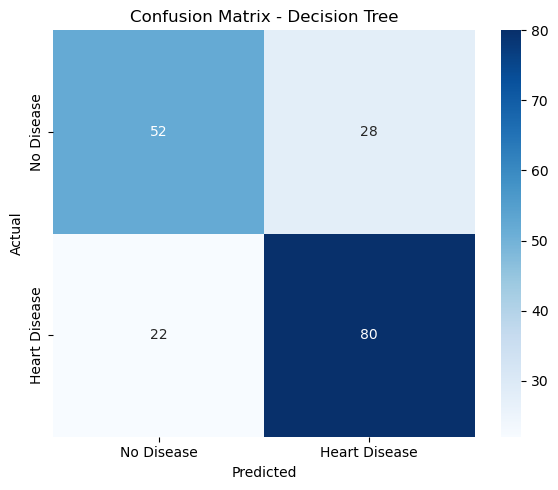

In [16]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Hyperparameter Tuning

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", round(grid_search.best_score_, 4))

best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test)
y_prob_best = best_dt.predict_proba(X_test)[:, 1]

print("\nTuned Model Performance:")
print("Accuracy :", round(accuracy_score(y_test, y_pred_best), 4))
print("Precision:", round(precision_score(y_test, y_pred_best), 4))
print("Recall   :", round(recall_score(y_test, y_pred_best), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_best), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_best), 4))

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV F1 Score: 0.7859

Tuned Model Performance:
Accuracy : 0.6538
Precision: 0.697
Recall   : 0.6765
F1-Score : 0.6866
ROC-AUC  : 0.713


# Model Evaluation and Visualization

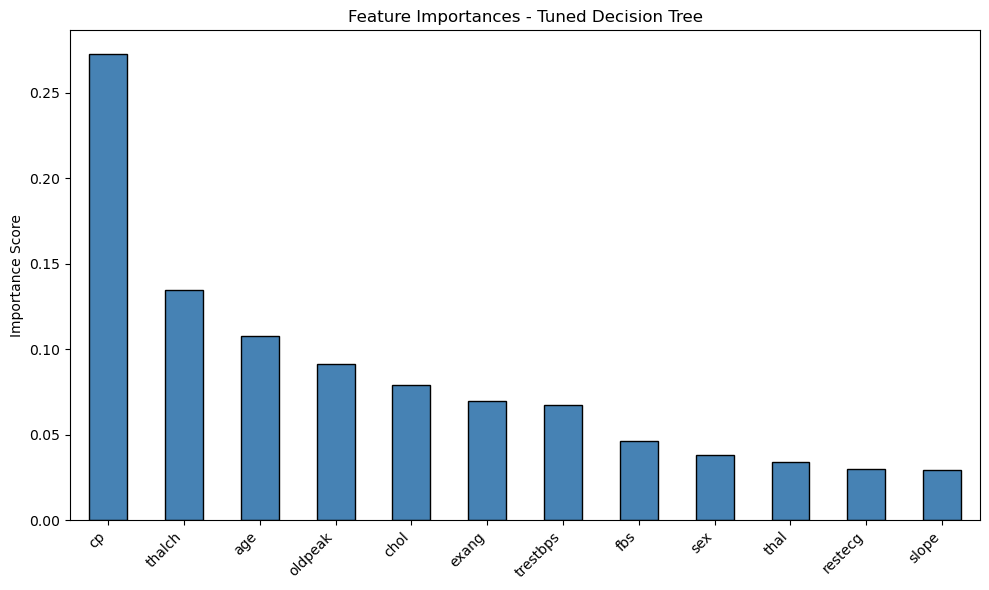

cp          0.273019
thalch      0.134718
age         0.107787
oldpeak     0.091476
chol        0.079146
exang       0.069634
trestbps    0.067413
fbs         0.046115
sex         0.037801
thal        0.033765
restecg     0.029751
slope       0.029375
dtype: float64


In [22]:
feature_importance = pd.Series(best_dt.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importances - Tuned Decision Tree')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print(feature_importance)

# Decision Tree Visualization

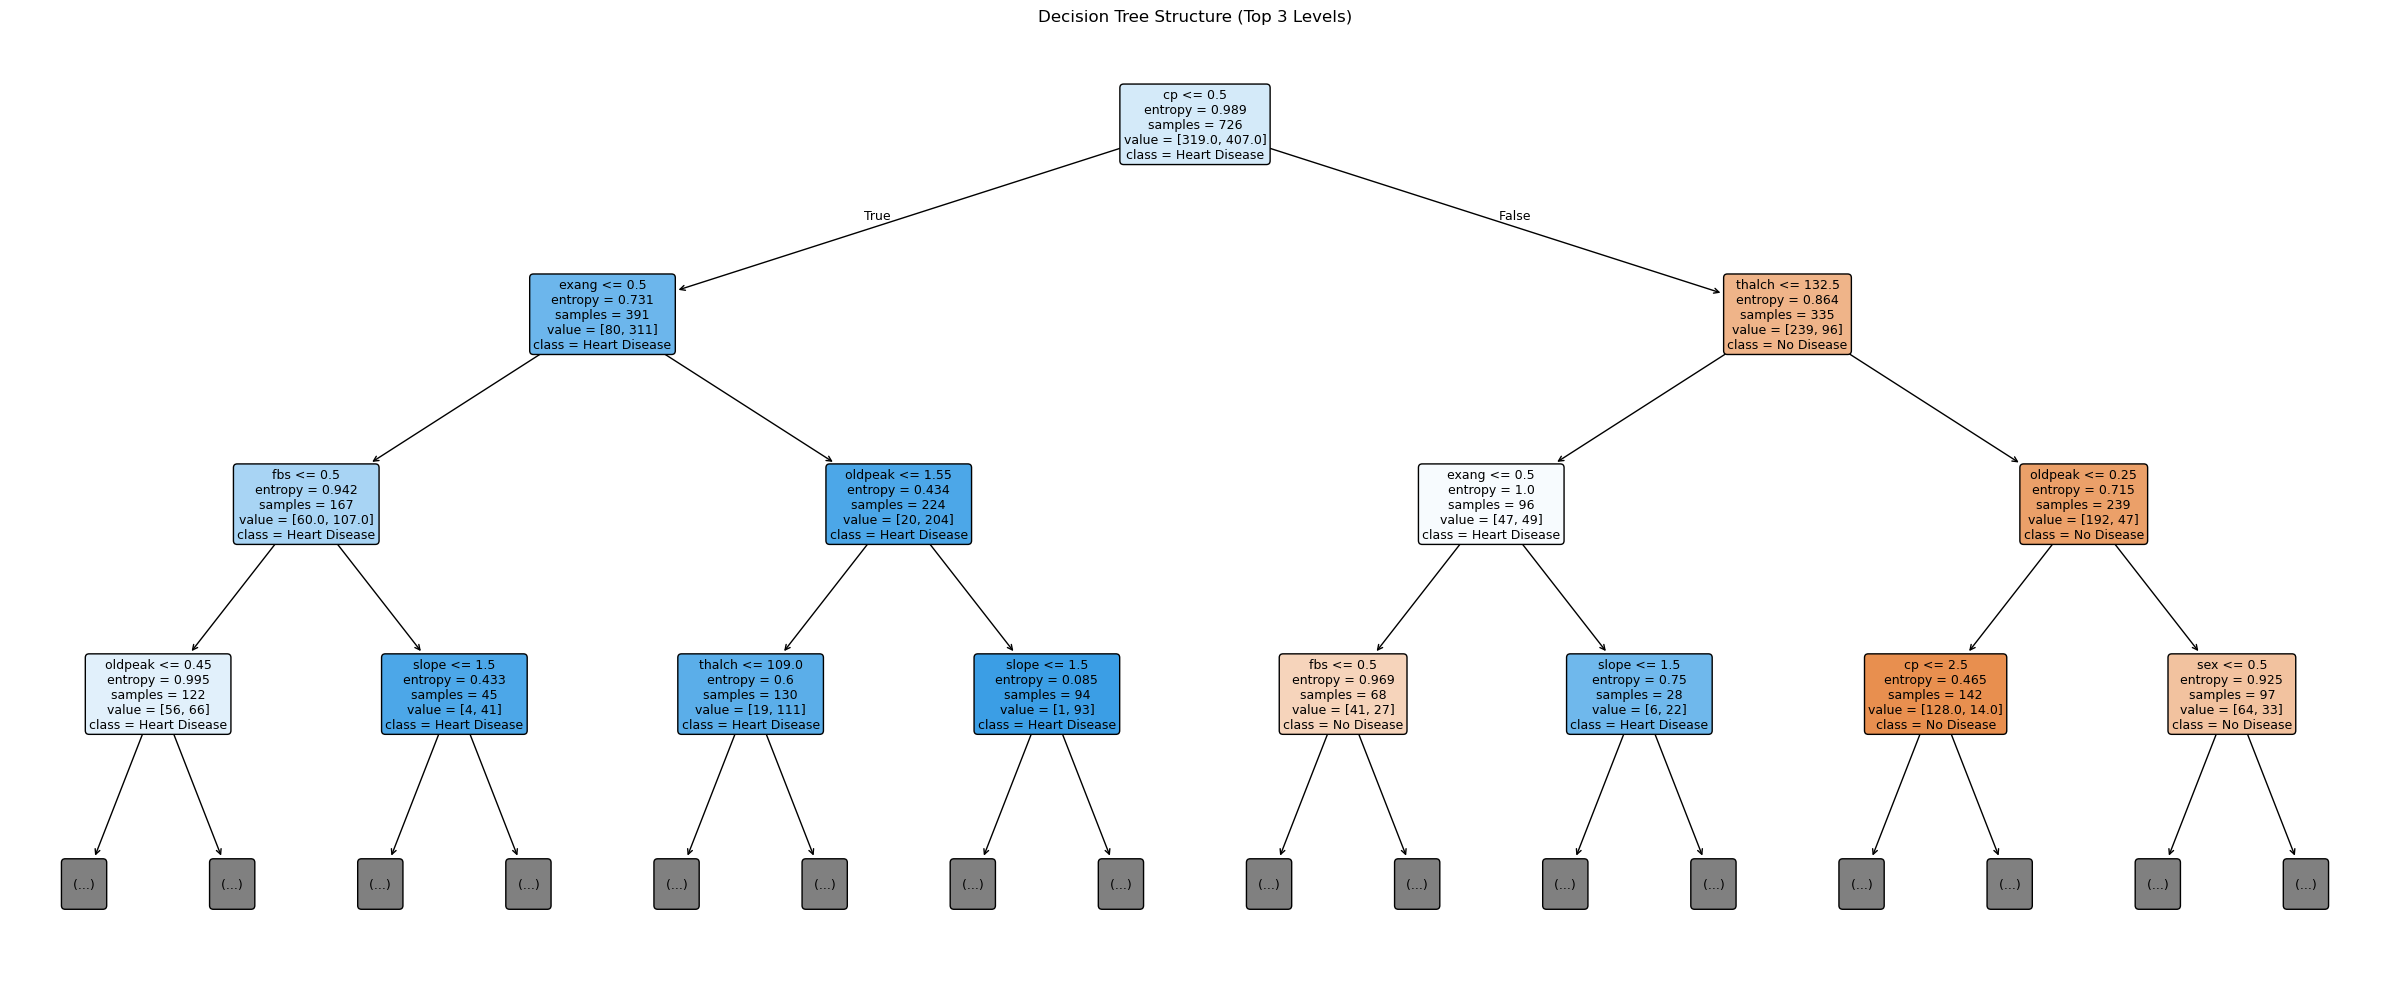

In [19]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 10))
plot_tree(
    best_dt,
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Heart Disease'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)
plt.title('Decision Tree Structure (Top 3 Levels)')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150)
plt.show()

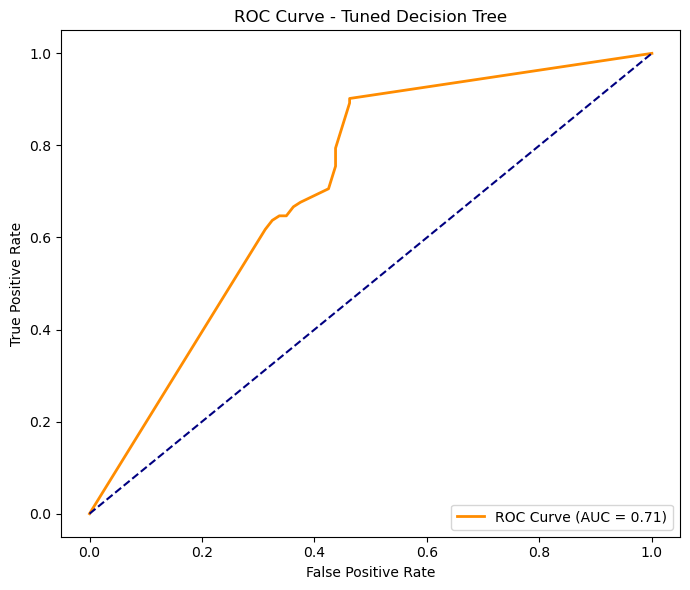

In [20]:
#ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc_score = roc_auc_score(y_test, y_prob_best)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Decision Tree')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

   Metric  Default DT  Tuned DT
 Accuracy      0.7253    0.6538
Precision      0.7407    0.6970
   Recall      0.7843    0.6765
 F1-Score      0.7619    0.6866
  ROC-AUC      0.7172    0.7130


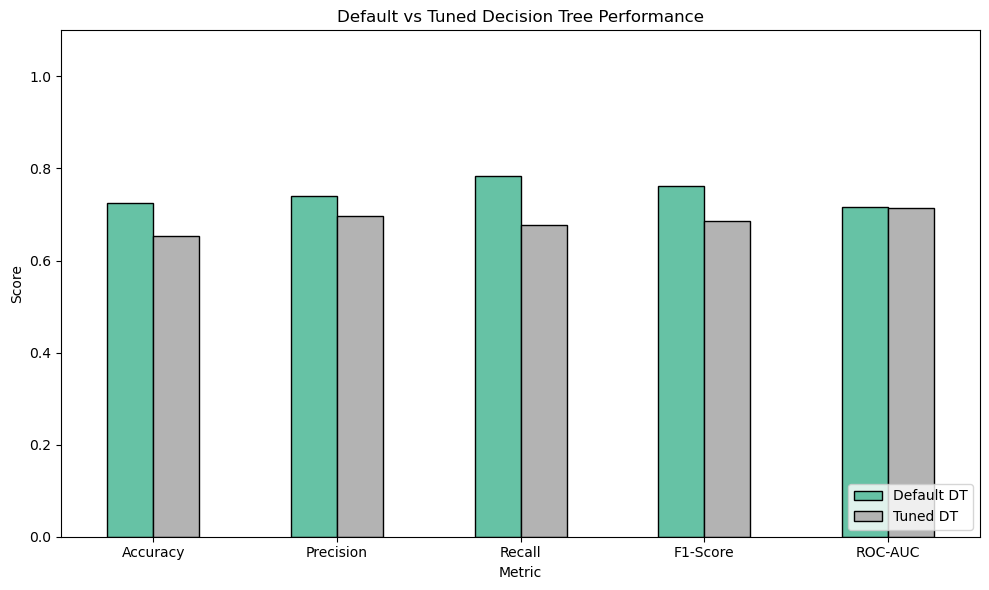

In [21]:
# Before vs After Tuning Comparison
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Default DT': [
        round(accuracy_score(y_test, y_pred), 4),
        round(precision_score(y_test, y_pred), 4),
        round(recall_score(y_test, y_pred), 4),
        round(f1_score(y_test, y_pred), 4),
        round(roc_auc_score(y_test, y_prob), 4)
    ],
    'Tuned DT': [
        round(accuracy_score(y_test, y_pred_best), 4),
        round(precision_score(y_test, y_pred_best), 4),
        round(recall_score(y_test, y_pred_best), 4),
        round(f1_score(y_test, y_pred_best), 4),
        round(roc_auc_score(y_test, y_prob_best), 4)
    ]
})
print(results.to_string(index=False))

results.set_index('Metric').plot(kind='bar', figsize=(10, 6), colormap='Set2', edgecolor='black')
plt.title('Default vs Tuned Decision Tree Performance')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

# Interview Question 1

What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
Decision tree models have several important hyperparameters that control the structure and complexity of the tree:

1. max_depth
This parameter controls the maximum depth of the tree. A smaller value creates a simpler, more generalized model and helps prevent overfitting. If set to None, the tree grows until all leaves are pure, which often leads to overfitting on training data.

2. min_samples_split
This defines the minimum number of samples required to split an internal node. A higher value prevents the tree from creating splits for very small groups of samples, which reduces overfitting and makes the model more generalized.

3. min_samples_leaf
This sets the minimum number of samples that must be present in a leaf node. Increasing this value smooths the model, especially in regression tasks, and prevents the tree from memorizing noise in the training data.

4. criterion
This defines the function used to measure the quality of a split. Two commonly used criteria are:

Gini Impurity — measures the probability of a randomly chosen element being incorrectly classified.

Entropy (Information Gain) — measures the amount of information gained from a split. Both give similar results, but entropy is slightly more computationally expensive.

5. max_features
This controls the number of features to consider when looking for the best split. Reducing this value introduces randomness and can help reduce variance in the model.

6. max_leaf_nodes
This limits the total number of leaf nodes in the tree. It constrains tree growth and helps in building a more compact and interpretable model.

Effect on Performance:

Too deep a tree → overfitting (high training accuracy, low test accuracy)

Too shallow a tree → underfitting (poor accuracy on both sets)

Proper tuning using GridSearchCV helps find the best balance between bias and variance.

# Interview Question 2

What is the difference between Label Encoding and One-Hot Encoding?
Both Label Encoding and One-Hot Encoding are techniques used to convert categorical (text) data into numerical format so that machine learning algorithms can process them. However, they differ significantly in approach and use cases.

Label Encoding

In Label Encoding, each unique category is assigned a unique integer value. For example:

Red - 0

Green - 1

Blue - 2

Advantages:

Simple and memory efficient — only one column is created.

Works well with tree-based models like Decision Trees and Random Forests, which do not assume any ordering.

Suitable for ordinal data where categories have a natural order (e.g., Low = 0, Medium = 1, High = 2).

Disadvantages:

Introduces a false ordinal relationship — the model may interpret 2 > 1 > 0, implying Blue is "greater than" Red, which is not true for nominal data.

Can mislead linear models like Logistic Regression or SVM.

One-Hot Encoding

In One-Hot Encoding, each unique category gets its own binary column (0 or 1). For example, the color column becomes:

Red	Green	Blue
1	0	0
0	1	0
0	0	1
Advantages:

No false ordering is introduced — treats all categories equally.

Works well with linear models, neural networks, and SVM.

Best for nominal data (categories with no natural order).

Disadvantages:

Creates many additional columns when the number of unique categories is large (curse of dimensionality).

Increases memory usage and training time.

| Situation                                        | Recommended Encoding              |
| ------------------------------------------------ | --------------------------------- |
| Ordinal data (Low, Medium, High)                 | Label Encoding                    |
| Nominal data with few categories                 | One-Hot Encoding                  |
| Tree-based models (Decision Tree, Random Forest) | Label Encoding is acceptable      |
| Linear models, SVM, Neural Networks              | One-Hot Encoding preferred        |
| Many unique categories (>10)                     | Label Encoding or Target Encoding |